# Multivariate Pattern Analysis 
Objective:
To uncover complex relationships between multiple features and their combined effect on churn.

Focus:
- Correlation analysis
- Partial correlations
- Feature interactions
- Risk surfaces

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("../dataset/processed/credit_card_clean.csv")

df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

In [7]:
num_df = df.select_dtypes(include=np.number)
num_df.corr()

,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,VIP_Flag
Attrition_Flag,1.000000,0.018203,0.018991,0.013687,-0.150005,0.152449,0.204491,-0.023873,-0.263053,-0.000285,-0.131063,-0.168598,-0.371403,-0.290054,-0.178410,-0.044131
Customer_Age,0.018203,1.000000,-0.122254,0.788912,-0.010931,0.054361,-0.018452,0.002476,0.014780,0.001151,-0.062042,-0.046446,-0.067097,-0.012143,0.007114,-0.013970
Dependent_count,0.018991,-0.122254,1.000000,-0.103062,-0.039076,-0.010768,-0.040505,0.068065,-0.002688,0.068291,-0.035439,0.025046,0.049912,0.011087,-0.037135,-0.007091
Months_on_book,0.013687,0.788912,-0.103062,1.000000,-0.009203,0.074164,-0.010774,0.007507,0.008623,0.006732,-0.048959,-0.038591,-0.049819,-0.014072,-0.007541,-0.014327
Total_Relationship_Count,-0.150005,-0.010931,-0.039076,-0.009203,1.000000,-0.003675,0.055203,-0.071386,0.013726,-0.072601,0.050119,-0.347229,-0.241891,0.040831,0.067663,-0.058459
Months_Inactive_12_mon,0.152449,0.054361,-0.010768,0.074164,-0.003675,1.000000,0.029493,-0.020394,-0.042210,-0.016605,-0.032247,-0.036982,-0.042787,-0.038989,-0.007503,-0.010568
Contacts_Count_12_mon,0.204491,-0.018452,-0.040505,-0.010774,0.055203,0.029493,1.000000,0.020817,-0.053913,0.025646,-0.024445,-0.112774,-0.152213,-0.094997,-0.055471,-0.001289
Credit_Limit,-0.023873,0.002476,0.068065,0.007507,-0.071386,-0.020394,0.020817,1.000000,0.042493,0.995981,0.012813,0.171730,0.075927,-0.002020,-0.482965,0.045465
Total_Revolving_Bal,-0.263053,0.014780,-0.002688,0.008623,0.013726,-0.042210,-0.053913,0.042493,1.000000,-0.047167,0.058174,0.064370,0.056060,0.089861,0.624022,0.037192
Avg_Open_To_Buy,-0.000285,0.001151,0.068291,0.006732,-0.072601,-0.016605,0.025646,0.995981,-0.047167,1.000000,0.007595,0.165923,0.070885,-0.010076,-0.538808,0.042121


# CORRELATION ANALYSIS

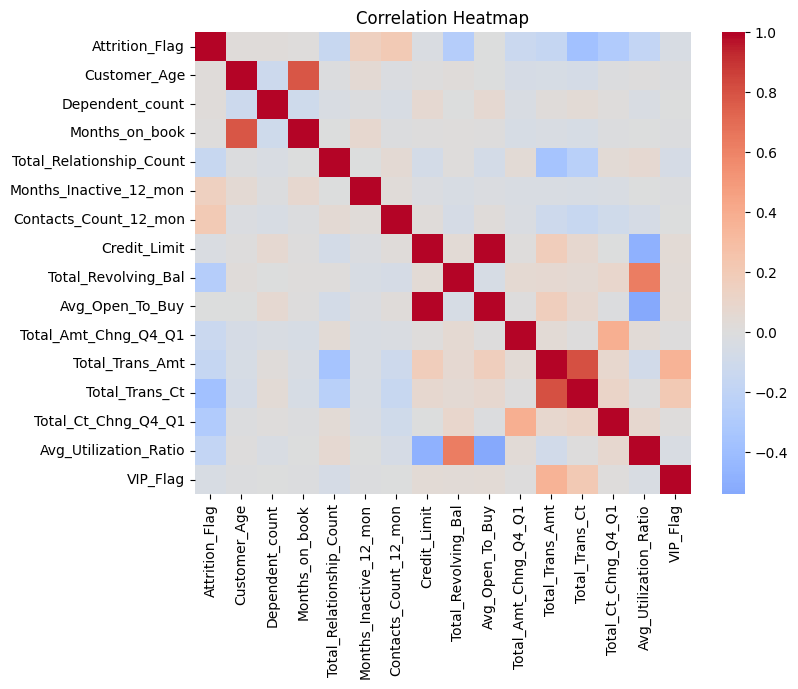

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Insight

- Pearson captures linear relationships
- Spearman captures monotonic (non-linear) relationships

Financial data often exhibits non-linear patterns → Spearman is critical

# PARTIAL CORRELATION

In [9]:
from sklearn.linear_model import LinearRegression

def partial_corr(x, y, z):
    model_x = LinearRegression().fit(z, x)
    model_y = LinearRegression().fit(z, y)
    
    res_x = x - model_x.predict(z)
    res_y = y - model_y.predict(z)
    
    return np.corrcoef(res_x, res_y)[0,1]

In [11]:
features = ["Transaction_Velocity", "Engagement", "Utilization"]

x = df["Transaction_Velocity"]
y = df["Attrition_Flag"]
z = df[["Engagement", "Utilization"]]

partial_corr(x, y, z)

KeyError: 'Transaction_Velocity'